### MCP的基础概念
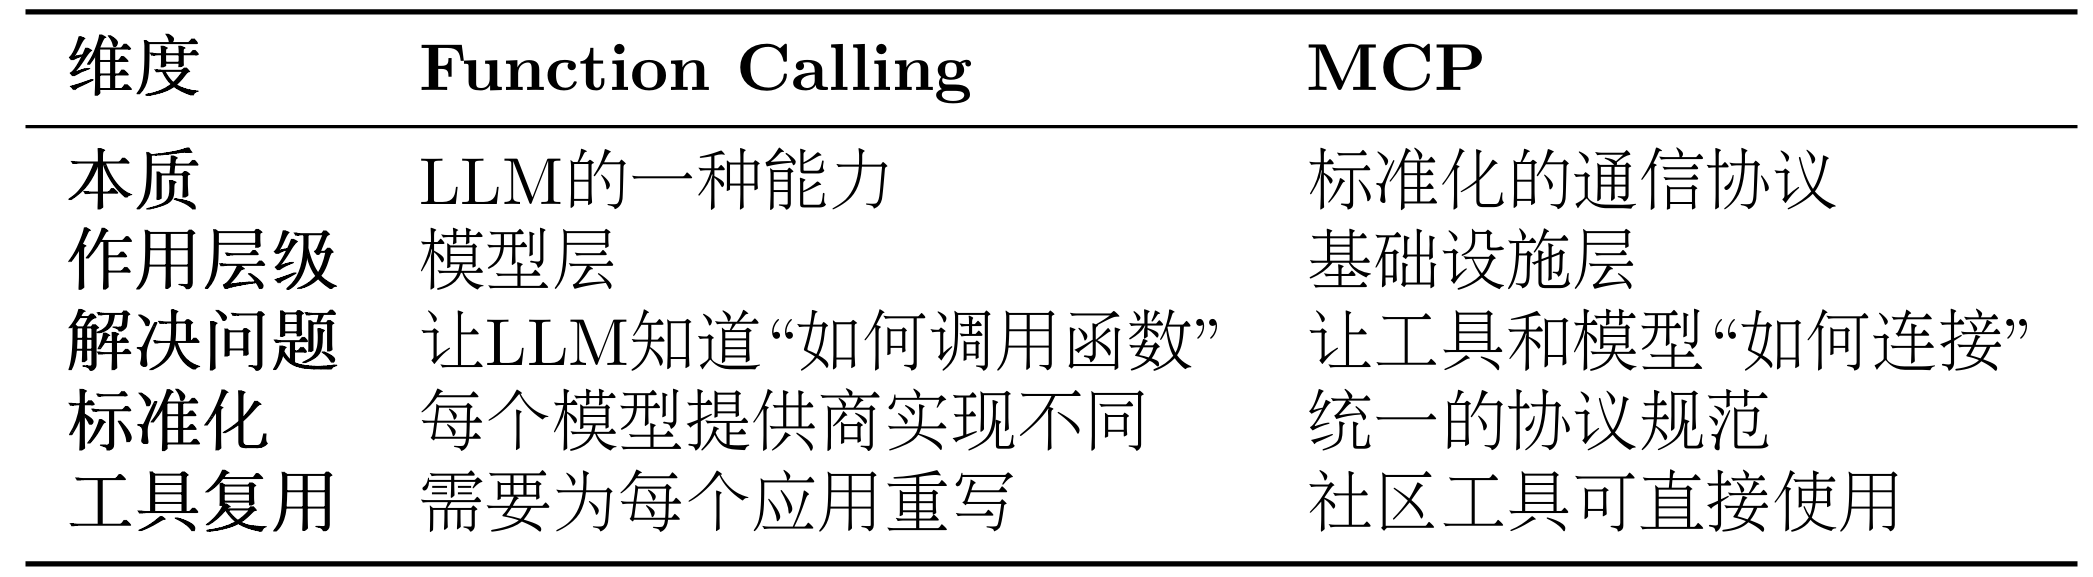


In [ ]:
import os
from typing import Annotated
from typing import Any, Dict, Generic, Optional, TypeVar

from mcp.server.fastmcp import FastMCP
from pydantic import BaseModel
from pydantic import Field

from build_mcp.common.config import load_config
from build_mcp.common.logger import get_logger
from build_mcp.services.gd_sdk import GdSDK

# 优先从环境变量里读取API_KEY，如果没有则从配置文件读取
env_api_key = os.getenv("API_KEY")
config = load_config("config.yaml")
if env_api_key:
  config["api_key"] = env_api_key

# 初始化 FastMCP 服务
mcp = FastMCP("amap-maps", description="高德地图 MCP 服务", version="1.0.0")
sdk = GdSDK(config=config, logger=get_logger(name="gd_sdk"))
logger = get_logger(name="amap-maps")

# 定义通用的 API 响应模型
T = TypeVar("T")


class ApiResponse(BaseModel, Generic[T]):
  success: bool
  data: Optional[T] = None
  error: Optional[str] = None
  meta: Optional[Dict[str, Any]] = None

  @classmethod
  def ok(cls, data: T, meta: Dict[str, Any] = None) -> "ApiResponse[T]":
    return cls(success=True, data=data, meta=meta)

  @classmethod
  def fail(cls, error: str, meta: Dict[str, Any] = None) -> "ApiResponse[None]":
    return cls(success=False, error=error, meta=meta)


# 定义 Prompt
@mcp.prompt(name="assistant", description="高德地图智能导航助手，支持IP定位、周边POI查询等")
def amap_assistant(query: str) -> str:
  return (
    "你是高德地图智能导航助手，精通 IP 定位 和 周边POI查询。请你根据用户的需求获取调取工具，获取用户需要的相关信息。\n"
    "## 调用工具的步骤：\n"
    "1. 调用 `locate_ip` 工具到获取用户的经纬度。\n"
    "2. 若成功获取经纬度，使用该经纬度调用 `search_nearby` 工具，结合搜索关键词进行周边信息的搜索。\n"
    "## 注意事项：\n"
    "- 不要主动要求用户提供经纬度信息，直接使用 `locate_ip` 工具获取。\n"
    "- 如果用户的需求中包含经纬度信息，可以直接使用该信息进行周边搜索。\n"
    f"用户的需求为：\n\n {query}。\n"
  )


@mcp.tool(name="locate_ip", description="获取用户的 IP 地址定位信息，返回省市区经纬度等信息。")
async def locate_ip(ip: Annotated[Optional[str], Field(description="用户的ip地址")] = None) -> ApiResponse:
  """
  根据 IP 地址定位位置。

  Args:
      ip (str): 要定位的 IP 地址。

  Returns:
      dict: 包含定位结果的字典。
  """
  logger.info(f"Locating IP: {ip}")
  try:
    result = await sdk.locate_ip(ip)
    if not result:
      ApiResponse.fail("定位结果为空，请检查日志，系统异常请检查相关日志，日志默认路径为/var/log/build_mcp。")
    logger.info(f"Locate IP result: {result}")
    return ApiResponse.ok(data=result, meta={"ip": ip})
  except Exception as e:
    logger.error(f"Error locating IP {ip}: {e}")
    return ApiResponse.fail(str(e))


@mcp.tool(name="search_nearby", description="根据经纬度和关键词进行周边搜索，返回指定半径内的 POI 列表。")
async def search_nearby(
        location: Annotated[str, Field(description="中心点经纬度，格式为 'lng,lat'，如 '116.397128,39.916527'")],
        keywords: Annotated[str, Field(description="搜索关键词，例如: '餐厅'。", min_length=0)] = "",
        types: Annotated[str, Field(description="POI 分类码，多个分类用逗号分隔")] = "",
        radius: Annotated[int, Field(description="搜索半径（米），最大50000", ge=0, le=50000)] = 1000,
        page_num: Annotated[int, Field(description="页码，从1开始", ge=1)] = 1,
        page_size: Annotated[int, Field(description="每页数量，最大25", ge=1, le=25)] = 20,
) -> ApiResponse:
  """
   周边搜索。

   Args:
       location (str): 中心点经纬度，格式为 "lng,lat"。
       keywords (str, optional): 搜索关键词，默认为空。
       types (str, optional): POI 分类，默认为空。
       radius (int, optional): 搜索半径（米），最大 50000，默认为 1000。
       page_num (int, optional): 页码，默认为 1。
       page_size (int, optional): 每页数量，最大 25，默认为 10。

   Returns:
       dict: 包含搜索结果的字典。
  """
  logger.info(f"Searching nearby: location={location}, keywords={keywords}, types={types}, radius={radius}, page_num={page_num}, page_size={page_size}")
  try:
    result = await sdk.search_nearby(location=location, keywords=keywords, types=types, radius=radius, page_num=page_num, page_size=page_size)
    if not result:
      return ApiResponse.fail("搜索结果为空，请检查日志，系统异常请检查相关日志，日志默认路径为/var/log/build_mcp。")
    logger.info(f"Search nearby result: {result}")
    return ApiResponse.ok(data=result, meta={
      "location": location,
      "keywords": keywords,
      "types": types,
      "radius": radius,
      "page_num": page_num,
      "page_size": page_size
    })
  except Exception as e:
    logger.error(f"Error searching nearby: {e}")
    return ApiResponse.fail(str(e))